In [1]:
# database connection
from fetch_data import DataFetcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# fetch data
symbol = 'NG'
data_fetcher = DataFetcher()
NG_futures_df = (
    data_fetcher.fetch_data(symbol, limit=5000)
    .sort_values('time')
    .reset_index(drop=True)
)
NG_futures_df['returns'] = np.log(NG_futures_df['close'] / NG_futures_df['close'].shift(1))
NG_futures_df.drop(columns=['open', 'high', 'low'], inplace=True)
Macro_df = data_fetcher.fetch_macro_data(limit=5000)
len_slow_features = Macro_df.shape[1] - 1  # exclude 'time' column

# Fetch global macro data 
global_macro_df = data_fetcher.fetch_global_macro_data(limit=5000)
len_slow_features += global_macro_df.shape[1] - 1  # add global macro columns (exclude 'time')

# Merge all data sources
data = pd.merge(NG_futures_df, Macro_df, on='time', how='inner')
data = pd.merge(data, global_macro_df, on='time', how='inner')
data = data.sort_values('time').reset_index(drop=True)

# EWMA volatility - smooth conditional vol level (comparable to what GARCH estimates)
ewma_span = 10
data['ewma_vol'] = data['returns'].ewm(span=ewma_span).std()
data['lagged_vol'] = data['ewma_vol']
data['target_vol'] = data['ewma_vol'].shift(-1)

# Keep raw |return| for VaR backtesting later
data['abs_return'] = data['returns'].abs()

data = data.dropna(subset=['returns', 'ewma_vol', 'target_vol']).reset_index(drop=True)
data.drop(columns=['time', 'symbol', 'ewma_vol'], inplace=True)

# Forward-fill then back-fill any NaN in global macro columns (macro data is lower frequency)
data = data.ffill().bfill()

print(f"Features: {[c for c in data.columns if c != 'target_vol']}")
print(data.head())

[*********************100%***********************]  1 of 1 completed


Features: ['volume', 'close', 'returns', 'treas_5y_close', 'treas_2y_close', 'vix_close', 'credit_spreads_ig_credit_spread', 'credit_spreads_high_yield_spread', 'growth_nonfarm_payrolls', 'growth_unemployment_rate', 'growth_manufacturing_capacity_util', 'growth_industrial_production', 'growth_retail_sales', 'growth_gdp', 'growth_consumer_sentiment', 'growth_manufacturing_employment', 'inflation_cpi', 'inflation_core_cpi', 'inflation_core_pce', 'inflation_breakeven_5y', 'liquidity_m2_money_supply', 'liquidity_ted_spread', 'liquidity_fed_balance_sheet', 'market_vix', 'market_dxy', 'market_tips_10y', 'market_gdp_nowcast', 'market_wti_crude', 'yield_curve_treasury_2y', 'yield_curve_treasury_10y', 'yield_curve_yield_spread_10y_2y', 'yield_curve_fed_funds_rate', 'yield_curve_treasury_30y', 'yield_curve_sofr', 'yield_curve_butterfly_spread', 'lagged_vol', 'abs_return']
   volume  close   returns  treas_5y_close  treas_2y_close  vix_close  \
0  124921  2.910  0.007935      117.093750      107.

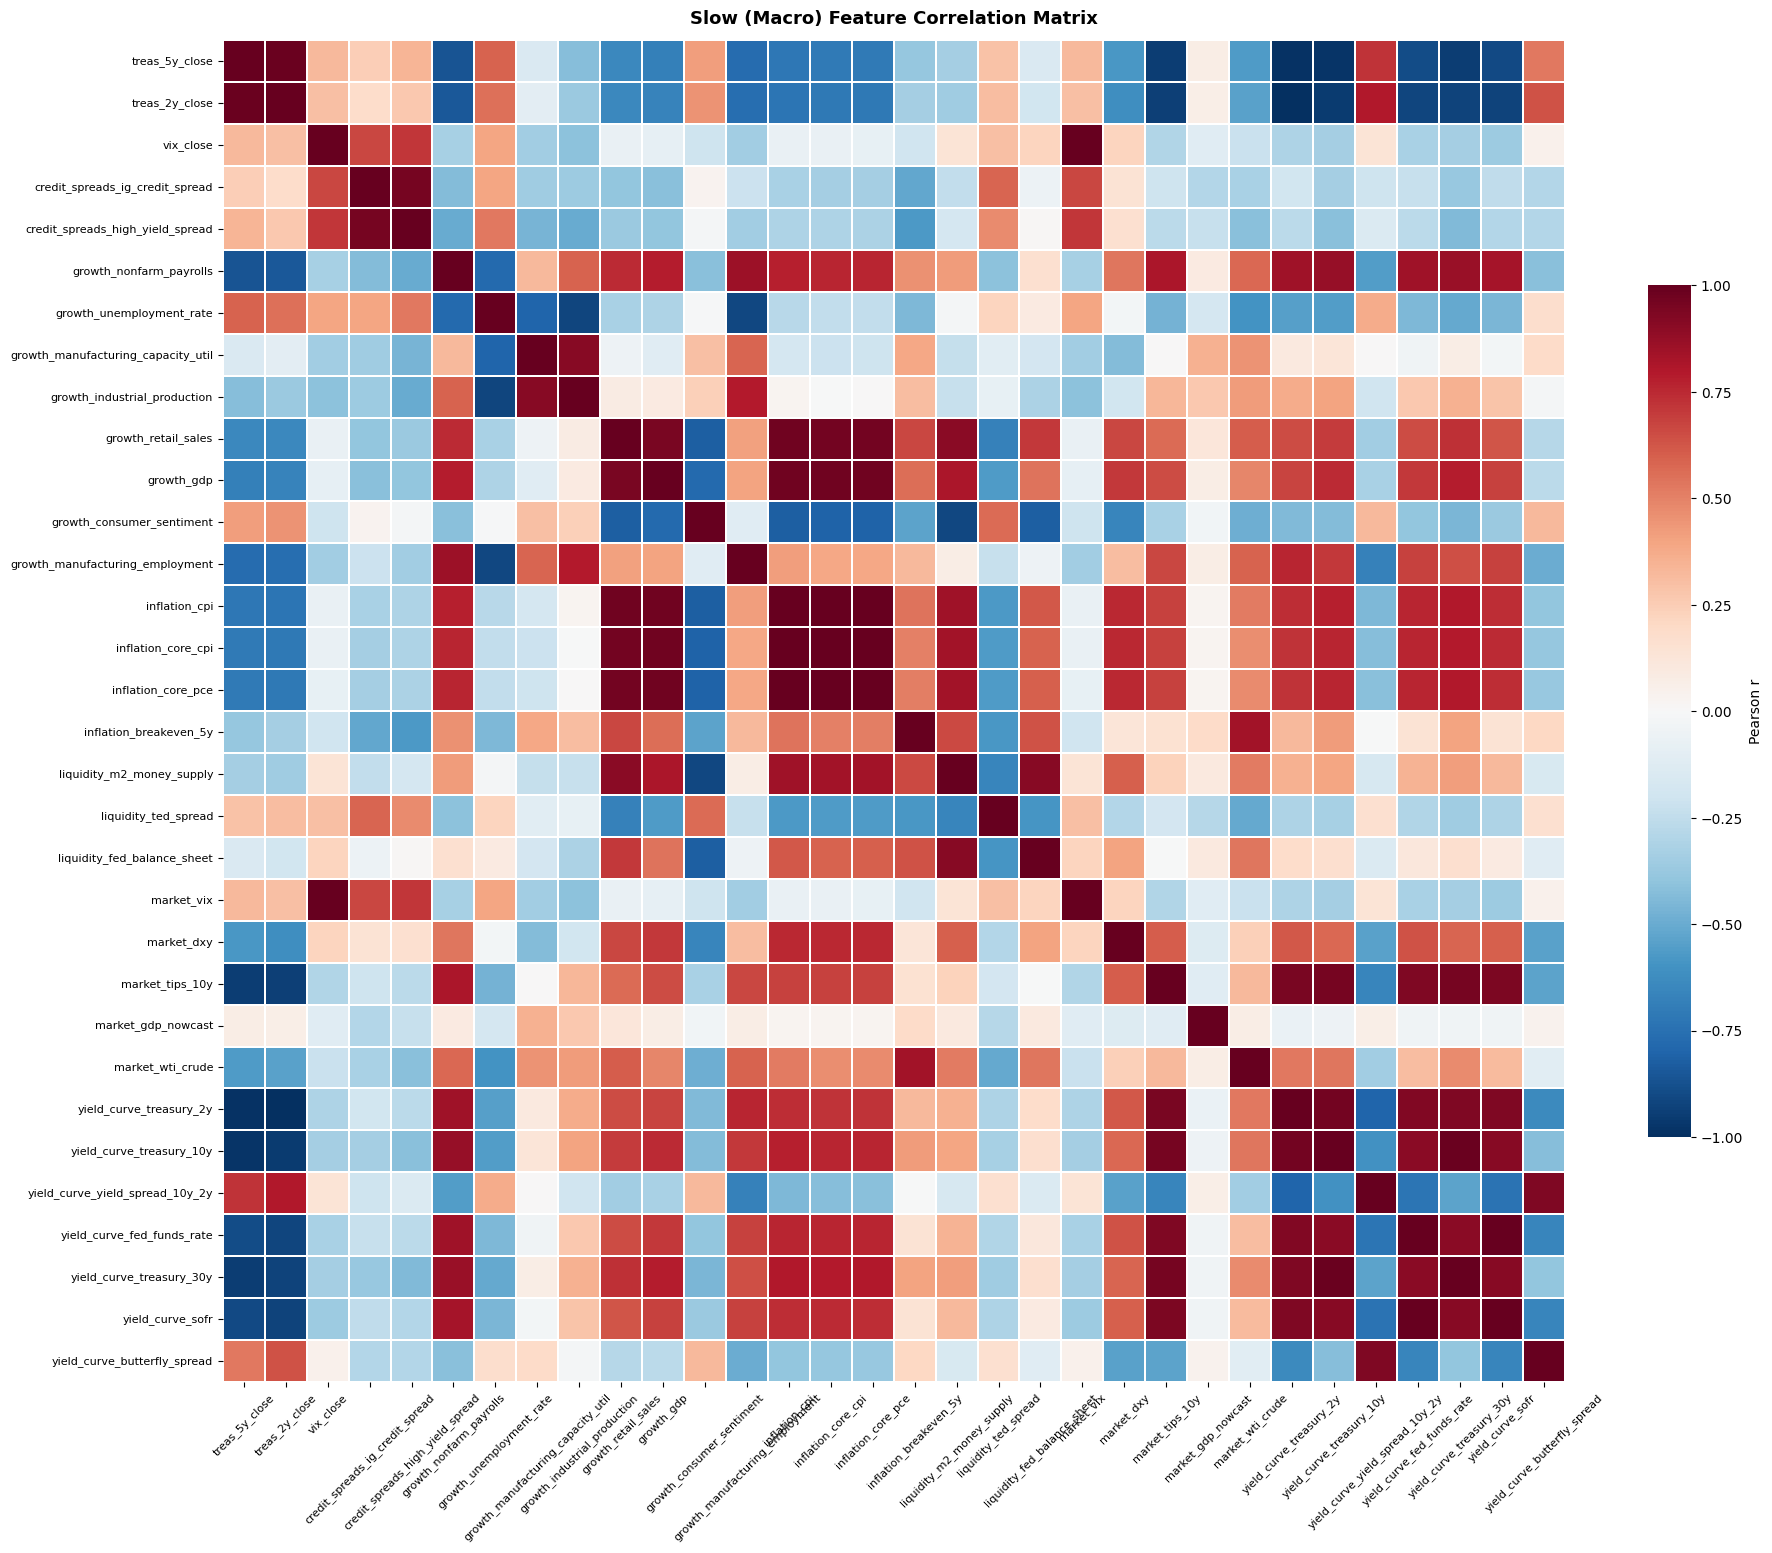

Highly correlated pairs (|r| > 0.85) — candidates for removal:
                       Feature A                          Feature B         r
                      market_vix                          vix_close  1.000000
              inflation_core_cpi                 inflation_core_pce  0.999732
                  treas_2y_close            yield_curve_treasury_2y -0.998804
              inflation_core_pce                      inflation_cpi  0.997684
              inflation_core_cpi                      inflation_cpi  0.997325
      yield_curve_fed_funds_rate                   yield_curve_sofr  0.993374
        yield_curve_treasury_10y           yield_curve_treasury_30y  0.989820
                  treas_2y_close                     treas_5y_close  0.989633
                  treas_5y_close            yield_curve_treasury_2y -0.988375
                  treas_5y_close           yield_curve_treasury_10y -0.982019
                      growth_gdp                 inflation_core_pce  0.976207
 

In [ ]:
import seaborn as sns

# --- Correlation heatmap of slow (macro) features ---

fast_feature_names_tmp = ['close', 'volume', 'returns', 'lagged_vol', 'abs_return', 'target_vol']
slow_cols = [c for c in data.columns if c not in fast_feature_names_tmp]

corr = data[slow_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(slow_cols) * 0.6), max(8, len(slow_cols) * 0.5)))
sns.heatmap(
    corr,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=len(slow_cols) <= 20,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
)
ax.set_title('Slow (Macro) Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.85)
high_corr = (
    corr.where(lambda df: (df.abs() > 0.85) & (df != 1.0))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
    .query('`Feature A` < `Feature B`')   # deduplicate
    .sort_values('r', key=abs, ascending=False)
)

if high_corr.empty:
    print("No feature pairs with |r| > 0.85")
else:
    print(f"Highly correlated pairs (|r| > 0.85) = candidates for removal:")
    print(high_corr.to_string(index=False))


In [4]:
# ### Feature pruning: remove redundant slow features ###
# Each drop is justified by a specific high-correlation pair

cols_to_drop = [
    # VIX: market_vix == vix_close (r=1.00) - keep vix_close (used in surface plot)
    'market_vix',

    # Inflation: core_cpi ≈ core_pce ≈ cpi (r>0.997) - keep inflation_cpi (broadest headline)
    'inflation_core_cpi',
    'inflation_core_pce',

    # Treasuries: treas_2y_close = −yield_curve_treasury_2y (r=−0.999) - keep yield_curve feature
    # treas_5y_close redundant with 2y, 10y, SOFR (r>0.95 with all) - drop both price series
    'treas_2y_close',
    'treas_5y_close',

    # Yield curve: 30y ≈ 10y (r=0.990) - keep 10y (benchmark tenor)
    'yield_curve_treasury_30y',

    # Short rates: SOFR ≈ fed_funds_rate (r=0.993) - keep fed_funds_rate (policy rate)
    'yield_curve_sofr',

    # Curve shape: butterfly_spread ≈ yield_spread_10y_2y (r=0.934)
    # - keep yield_spread_10y_2y (used in regime bucketing)
    'yield_curve_butterfly_spread',

    # Credit: IG spread ≈ HY spread (r=0.956) - keep high_yield (wider, captures more stress)
    'credit_spreads_ig_credit_spread',

    # Labor: manufacturing_employment ≈ nonfarm_payrolls (r=0.858) & ≈ −unemployment (r=−0.914)
    # nonfarm_payrolls is the broader aggregate - drop manufacturing sub-series
    'growth_manufacturing_employment',

    # Liquidity: fed_balance_sheet ≈ m2_money_supply (r=0.908) - keep m2 (broader measure)
    'liquidity_fed_balance_sheet',
]

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in data.columns]
data.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} redundant features:")
for c in cols_to_drop:
    print(f"  - {c}")
print(f"\nRemaining columns ({len(data.columns)}): {list(data.columns)}")


Dropped 11 redundant features:
  - market_vix
  - inflation_core_cpi
  - inflation_core_pce
  - treas_2y_close
  - treas_5y_close
  - yield_curve_treasury_30y
  - yield_curve_sofr
  - yield_curve_butterfly_spread
  - credit_spreads_ig_credit_spread
  - growth_manufacturing_employment
  - liquidity_fed_balance_sheet

Remaining columns (27): ['volume', 'close', 'returns', 'vix_close', 'credit_spreads_high_yield_spread', 'growth_nonfarm_payrolls', 'growth_unemployment_rate', 'growth_manufacturing_capacity_util', 'growth_industrial_production', 'growth_retail_sales', 'growth_gdp', 'growth_consumer_sentiment', 'inflation_cpi', 'inflation_breakeven_5y', 'liquidity_m2_money_supply', 'liquidity_ted_spread', 'market_dxy', 'market_tips_10y', 'market_gdp_nowcast', 'market_wti_crude', 'yield_curve_treasury_2y', 'yield_curve_treasury_10y', 'yield_curve_yield_spread_10y_2y', 'yield_curve_fed_funds_rate', 'lagged_vol', 'target_vol', 'abs_return']


In [6]:
# Save processed data to CSV for use by surrogate.ipynb
DATA_CSV = '../datasets/processed_data.csv'
data.to_csv(DATA_CSV, index=False)
print(f"Saved processed data → {DATA_CSV}")
print(f"Shape: {data.shape}")
print(f"Columns ({len(data.columns)}): {list(data.columns)}")


Saved processed data → ../datasets/processed_data.csv
Shape: (2017, 27)
Columns (27): ['volume', 'close', 'returns', 'vix_close', 'credit_spreads_high_yield_spread', 'growth_nonfarm_payrolls', 'growth_unemployment_rate', 'growth_manufacturing_capacity_util', 'growth_industrial_production', 'growth_retail_sales', 'growth_gdp', 'growth_consumer_sentiment', 'inflation_cpi', 'inflation_breakeven_5y', 'liquidity_m2_money_supply', 'liquidity_ted_spread', 'market_dxy', 'market_tips_10y', 'market_gdp_nowcast', 'market_wti_crude', 'yield_curve_treasury_2y', 'yield_curve_treasury_10y', 'yield_curve_yield_spread_10y_2y', 'yield_curve_fed_funds_rate', 'lagged_vol', 'target_vol', 'abs_return']


In [ ]:
train_split = int(0.8 * len(data))
realized_vols = data['lagged_vol'].values[train_split:]

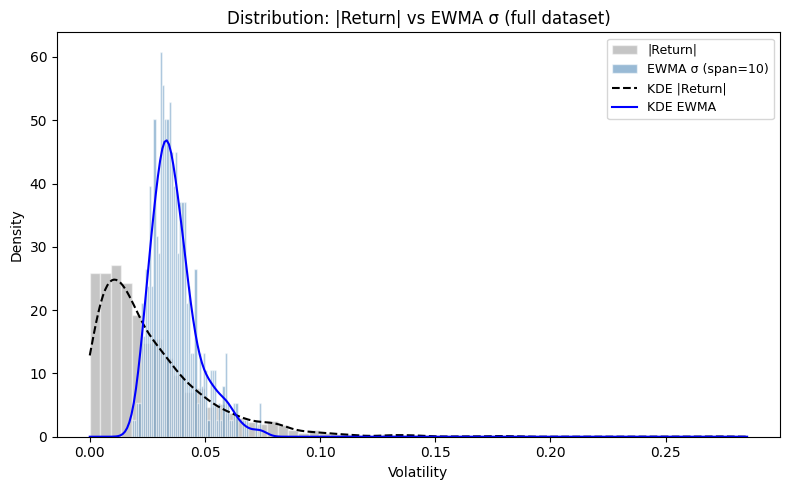

==============Shapiro-Wilk Normality Test==============
  (higher p-value = more consistent with normality)

                                 |Return| EWMA σ
  ──────────────────────────────────────────────────
  W statistic                        0.8241     0.9322
  p-value                        0.000000000000 0.000000000001

  EWMA σ is more consistent with normality (higher p-value)

Metric                        |Return|       EWMA σ
-------------------------------------------------
Mean                          0.026817     0.036798
Median                        0.019669     0.034872
Std                           0.024636     0.009988
Skewness                         2.185        1.079
Excess Kurtosis                  9.113        1.289
P5                            0.002147     0.023987
P95                           0.075571     0.057957
ewma p val 1.3952819444589449e-12
raw p val 1.76774678102569e-42


In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

sigma = '\u03c3'

# Full dataset: compare |return| vs EWMA σ across all observations
raw_realized = data['abs_return'].values

# ── Plot 1: Overlaid histograms ──
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.hist(raw_realized, bins=60, density=True, alpha=0.45, color='grey', edgecolor='white', label='|Return|')
ax1.hist(realized_vols, bins=60, density=True, alpha=0.55, color='steelblue', edgecolor='white', label=f'EWMA {sigma} (span={ewma_span})')
kde_raw = stats.gaussian_kde(raw_realized)
kde_ewma = stats.gaussian_kde(realized_vols)
xr = np.linspace(0, max(raw_realized.max(), realized_vols.max()) * 1.05, 300)
ax1.plot(xr, kde_raw(xr), 'k--', lw=1.5, label='KDE |Return|')
ax1.plot(xr, kde_ewma(xr), 'b-', lw=1.5, label='KDE EWMA')
ax1.set_xlabel('Volatility')
ax1.set_ylabel('Density')
ax1.set_title(f'Distribution: |Return| vs EWMA {sigma} (full dataset)')
ax1.legend(fontsize=9)
plt.tight_layout()
plt.show()

# -- Shapiro-Wilk normality test: compare p-values --
# H0: data is drawn from a normal distribution
print(f"{'Shapiro-Wilk Normality Test':=^55}")
print(f"  (higher p-value = more consistent with normality)\n")
print(f"  {'':30s} {'|Return|'} {'EWMA '+sigma}")
print(f"  {'-'*50}")

for name, arr in [('|Return|', raw_realized), (f'EWMA {sigma}', realized_vols)]:
    stat, pval = stats.shapiro(arr[:5000])  # Shapiro-Wilk limited to n<=5000
    if name == '|Return|':
        sw_raw, p_raw = stat, pval
    else:
        sw_ewma, p_ewma = stat, pval

print(f"  {'W statistic':30s} {sw_raw:>10.4f} {sw_ewma:>10.4f}")
print(f"  {'p-value':30s} {p_raw:.12f} {p_ewma:.12f}")
closer = '|Return|' if p_raw > p_ewma else f'EWMA {sigma}'
print(f"\n  {closer} is more consistent with normality (higher p-value)")

# -- Summary stats table --
ewma_label = f'EWMA {sigma}'
print()
print(f"{'Metric':<25} {'|Return|':>12} {ewma_label:>12}")
print(f"{'-'*49}")
print(f"{'Mean':<25} {raw_realized.mean():>12.6f} {realized_vols.mean():>12.6f}")
print(f"{'Median':<25} {np.median(raw_realized):>12.6f} {np.median(realized_vols):>12.6f}")
print(f"{'Std':<25} {raw_realized.std():>12.6f} {realized_vols.std():>12.6f}")
print(f"{'Skewness':<25} {stats.skew(raw_realized):>12.3f} {stats.skew(realized_vols):>12.3f}")
print(f"{'Excess Kurtosis':<25} {stats.kurtosis(raw_realized):>12.3f} {stats.kurtosis(realized_vols):>12.3f}")
print(f"{'P5':<25} {np.percentile(raw_realized, 5):>12.6f} {np.percentile(realized_vols, 5):>12.6f}")
print(f"{'P95':<25} {np.percentile(raw_realized, 95):>12.6f} {np.percentile(realized_vols, 95):>12.6f}")


print(f'ewma p val {p_ewma}')
print(f'raw p val {p_raw}')